In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('top5-players.csv')

print(f"Datele au fost încărcate. Baza de date are {df.shape[0]} jucători și {df.shape[1]} coloane.")

Datele au fost încărcate. Baza de date are 2852 jucători și 37 coloane.


In [2]:
display(df.head())

print("\n--- Informatii generale ---")
df.info()

print("\n--- Valori lipsa per coloana ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,23.0,2000.0,20,13,...,0.00,0.07,0.07,0.00,0.07,0.00,0.06,0.06,0.00,0.06
1,2,Brenden Aaronson,us USA,"MF,FW",Union Berlin,de Bundesliga,22.0,2000.0,30,14,...,0.14,0.14,0.28,0.14,0.28,0.14,0.13,0.27,0.14,0.27
2,3,Paxten Aaronson,us USA,MF,Eint Frankfurt,de Bundesliga,19.0,2003.0,7,1,...,0.00,0.89,0.89,0.00,0.89,0.11,0.07,0.19,0.11,0.19
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,17.0,2006.0,1,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,5,Yunis Abdelhamid,ma MAR,DF,Reims,fr Ligue 1,35.0,1987.0,31,31,...,0.13,0.00,0.13,0.10,0.10,0.11,0.01,0.12,0.09,0.09



--- Informatii generale ---
<class 'pandas.DataFrame'>
RangeIndex: 2852 entries, 0 to 2851
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rk           2852 non-null   int64  
 1   Player       2852 non-null   str    
 2   Nation       2849 non-null   str    
 3   Pos          2852 non-null   str    
 4   Squad        2852 non-null   str    
 5   Comp         2852 non-null   str    
 6   Age          2848 non-null   float64
 7   Born         2848 non-null   float64
 8   MP           2852 non-null   int64  
 9   Starts       2852 non-null   int64  
 10  Min          2852 non-null   int64  
 11  90s          2852 non-null   float64
 12  Gls          2852 non-null   int64  
 13  Ast          2852 non-null   int64  
 14  G+A          2852 non-null   int64  
 15  G-PK         2852 non-null   int64  
 16  PK           2852 non-null   int64  
 17  PKatt        2852 non-null   int64  
 18  CrdY         2852 non-null   i

In [ ]:
df['Pos'] = df['Pos'].apply(lambda x: x.split(',')[0] if isinstance(x, str) else x)

jucatori_initial = len(df)
df = df[df['Min'] >= 450]
print(f"Am eliminat {jucatori_initial - len(df)} jucatori cu prea putine minute jucate.")

df = df.dropna()

print(f"Baza de date curatata a ramas cu {len(df)} jucatori gata pentru analiza.")

Am eliminat 889 jucători cu prea puține minute jucate.
Baza de date curățată a rămas cu 1962 jucători gata pentru analiză.


/tmp/ipykernel_15525/430532570.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pos', order=df['Pos'].value_counts().index, palette='viridis')
/home/zetplay/Documents/Proiecte/Proiect sisteme inteligente/env/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 539 (\N{LATIN SMALL LETTER T WITH COMMA BELOW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


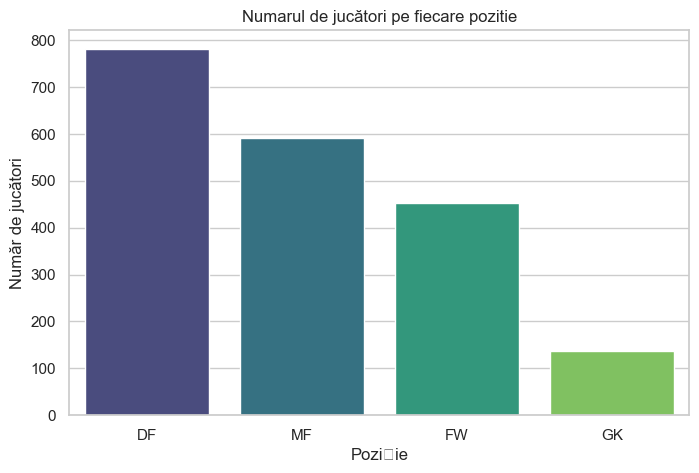

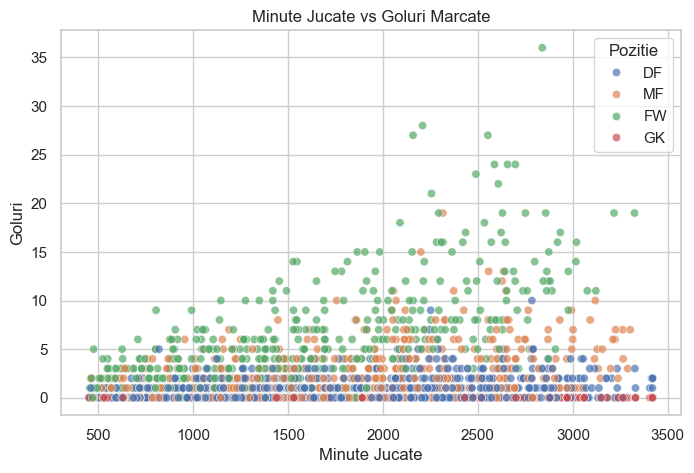

In [5]:
# Grafic 1: Distribuția jucătorilor pe poziții (după ce le-am standardizat)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Pos', order=df['Pos'].value_counts().index, palette='viridis')
plt.title('Numarul de jucători pe fiecare pozitie')
plt.xlabel('Poziție')
plt.ylabel('Număr de jucători')
plt.show()

# Grafic 2: Relația dintre Minute Jucate și Goluri marcate
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Min', y='Gls', hue='Pos', alpha=0.7)
plt.title('Minute Jucate vs Goluri Marcate')
plt.xlabel('Minute Jucate')
plt.ylabel('Goluri')
plt.legend(title='Pozitie')
plt.show()

In [6]:
df = df.drop(columns=['Rk'])

#'eng ENG' devine 'ENG'
df['Nation'] = df['Nation'].apply(lambda x: x.split(' ')[-1] if isinstance(x, str) else x)

#'eng Premier League' devine 'Premier League'
df['Comp'] = df['Comp'].apply(lambda x: ' '.join(x.split(' ')[1:]) if isinstance(x, str) else x)

df['Age'] = df['Age'].astype(int)
df['Born'] = df['Born'].astype(int)

display(df[['Player', 'Nation', 'Comp', 'Age']].head())

,Player,Nation,Comp,Age
0,Max Aarons,ENG,Premier League,23
1,Brenden Aaronson,USA,Bundesliga,22
4,Yunis Abdelhamid,MAR,Ligue 1,35
5,Salis Abdul Samed,GHA,Ligue 1,23
7,Laurent Abergel,FRA,Ligue 1,30


In [7]:
df.to_csv('top5-players-curatat.csv', index=False)
print("Fisierul curatat a fost salvat cu succes ca 'top5-players-curatat.csv'.")

Fisierul curatat a fost salvat cu succes ca 'top5-players-curatat.csv'.
